# **Library used**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For Holt-Winters!!
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# **Import Data**

In [20]:
file_names = [
    'data/2010-2011 Solar home electricity data.csv',
    'data/2011-2012 Solar home electricity data v2.csv',
    'data/2012-2013 Solar home electricity data v2.csv'
]

all_years_list = []

for name in file_names:

    try:
        # header=1 to skip the PDF description row
        temp_df = pd.read_csv(name, header=1)

        # Clean column names just in case
        temp_df.columns = [str(col).strip().lower() for col in temp_df.columns]

        # Find 'Date' and 'Category' by position or keyword
        date_col = next((c for c in temp_df.columns if 'date' in c), None)
        cat_col = next((c for c in temp_df.columns if 'consumption' in c or 'category' in c), None)

        if not date_col or not cat_col:
            print(f"Skipping {name}: Missing Date/Category columns.")
            continue

        # Select 48 columns by position (The last 48 columns)
        # In Ausgrid files, the 48 half-hour slots are always the last 48 columns.
        # Take the last 48 columns and rename them to 1-48 for consistency.
        power_data_cols = temp_df.columns[-48:].tolist()

        # Filter for General Consumption (GC)
        temp_gc = temp_df[temp_df[cat_col].astype(str).str.contains('GC', case=False, na=False)].copy()

        # Ensure data is numeric
        for col in power_data_cols:
            temp_gc[col] = pd.to_numeric(temp_gc[col], errors='coerce')

        # Aggregate: Mean of ALL customers
        daily_avg = temp_gc.groupby(date_col)[power_data_cols].mean().reset_index()

        # Rename columns to standard: 'Date', '1', '2', ..., '48'
        standard_names = ['Date'] + [str(i) for i in range(1, 49)]
        daily_avg.columns = standard_names

        all_years_list.append(daily_avg)
        print(f"SUCCESS: Processed {name} with 48 time slots.")

        del temp_df, temp_gc

    except Exception as e:
        print(f"Error at {name}: {e}")


SUCCESS: Processed /content/2010-2011 Solar home electricity data.csv with 48 time slots.
SUCCESS: Processed /content/2011-2012 Solar home electricity data v2.csv with 48 time slots.
SUCCESS: Processed /content/2012-2013 Solar home electricity data v2.csv with 48 time slots.


# **Transformation, Deseasonalization and Visualization**

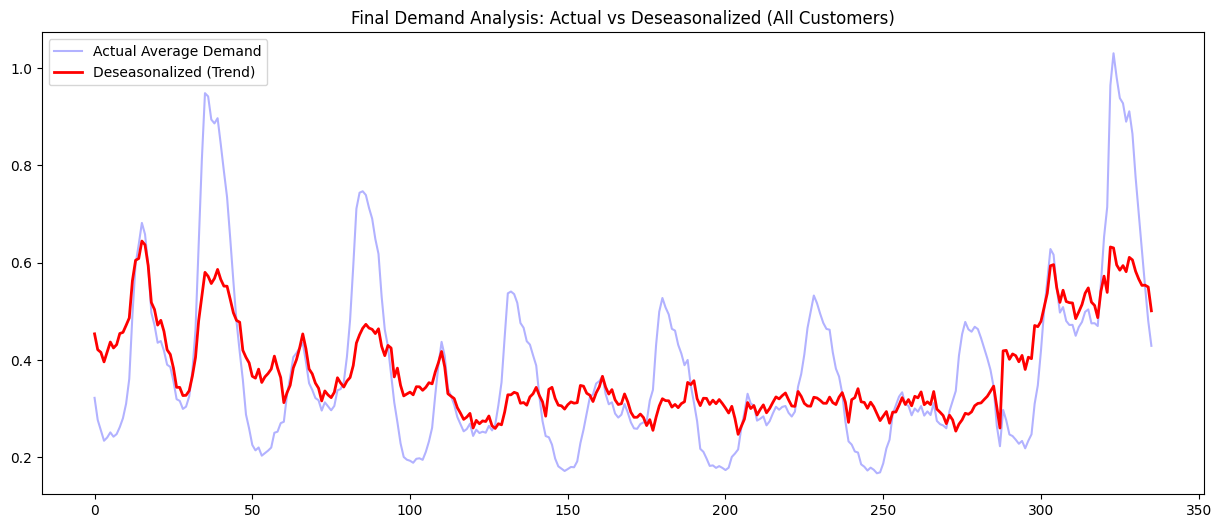

In [19]:
if all_years_list:
    df_combined = pd.concat(all_years_list, ignore_index=True)

    # Transformation
    time_periods = [str(i) for i in range(1, 49)]
    df_long = df_combined.melt(id_vars=['Date'], value_vars=time_periods,
                               var_name='Period', value_name='Avg_kWh')

    df_long['Date'] = pd.to_datetime(df_long['Date'], dayfirst=True)
    df_long['Period'] = df_long['Period'].astype(int)
    df_long = df_long.sort_values(['Date', 'Period']).reset_index(drop=True)

    # Deseasonalization (Lecture 6)
    grand_mean = df_long['Avg_kWh'].mean()
    seasonal_indices = df_long.groupby('Period')['Avg_kWh'].mean() / grand_mean
    df_long['Seasonal_Index'] = df_long['Period'].map(seasonal_indices)
    df_long['Deseasonalized_kWh'] = df_long['Avg_kWh'] / df_long['Seasonal_Index']

    # Visualization
    plt.figure(figsize=(15, 6))
    plt.plot(df_long['Avg_kWh'][:336], label='Actual Average Demand', color='blue', alpha=0.3)
    plt.plot(df_long['Deseasonalized_kWh'][:336], label='Deseasonalized (Trend)', color='red', linewidth=2)
    plt.title('Final Demand Analysis: Actual vs Deseasonalized (All Customers)')
    plt.legend()
    plt.show()
else:
    print("Check if your files are actually .csv and have 48 data columns at the end.")